In [1]:
import os
import pickle

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from linearmodels.panel import PanelOLS

import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.regression.linear_model import OLS
from statsmodels.tools.tools import add_constant

from arch.bootstrap import StationaryBootstrap

from scipy import stats
from scipy.stats import pearsonr, spearmanr, f_oneway
from scipy.stats.mstats import winsorize

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)

In [2]:
# !pip install --upgrade pip
# !pip install linearmodels
# !pip install xlsxwriter

In [3]:
np.random.seed(42)

In [4]:
from utils import *

In [5]:
def ols_with_cluster(data, target, x_vars, cluster_var):

    subset = data.dropna(subset=[target] + x_vars + [cluster_var])
    X = add_constant(subset[x_vars])
    y = subset[target]
    clusters = subset[cluster_var]
    
    model = OLS(y, X).fit()

    results = model.get_robustcov_results(cov_type='cluster', groups=clusters)
    return results


def ols_new_west(data, x_vars, target):
    subset = data.dropna(subset=[target] + x_vars)
    
    formula = f"{target} ~ {' + '.join(x_vars)}"
    
    model = smf.ols(formula, data=subset)
    results = model.fit(cov_type='HAC', cov_kwds={'maxlags': 12})
    
    return results


def fit_one_factor(df, sentiment, return_names, control_variables=None):
    features_res = {}
    
    for target in return_names:
#         if 'growth_MB' in sentiment:
        if control_variables is not None:
            results = ols_new_west(df, [sentiment] + control_variables, target)
        else:
            results = ols_new_west(df, [sentiment], target)
        
        features_res[target] = {}
        features_res[target]['model'] = results
        features_res[target]['coef'] = round(results.params[sentiment], 3)
        features_res[target]['t'] = round(results.tvalues[sentiment], 3)
        features_res[target]['r2_adj'] = round(100*results.rsquared_adj, 3)
        
        pval = round(results.pvalues[sentiment], 3)
        
        features_res[target]['pval'] = pval
        if pval <= 0.01:
            sgnf = '***'
        elif 0.01 < pval <= 0.05:
            sgnf = '**'
        elif 0.05 < pval <= 0.1:
            sgnf = '*'
        else:
            sgnf = ''
        features_res[target]['sgnf'] = sgnf
        
    table_res = pd.DataFrame(features_res).T.drop('model', axis=1)
    table_res['coef'] = table_res['coef'].astype(str) + table_res['sgnf']
    table_res = table_res[['coef', 't', 'r2_adj', 'pval']]
        
    return features_res, table_res

## Data

In [6]:
sent_df = pd.read_csv("frankel_sentiments_full_sample_with_growth.tsv.gz", sep='\t', compression='gzip')

sent_df['year'] = sent_df['FILING_DATE'].apply(lambda x: str(x)[:4])
sent_df['year_month'] = sent_df['FILING_DATE'].astype(str).str[:6]

sent_df = sent_df[sent_df['year'] >= '2003'].reset_index(drop=True)

In [7]:
sent_df = sent_df[(sent_df['industry_code'] != 'Money') & (sent_df['industry_code'] != 'Utils')].copy().reset_index(drop=True)

In [8]:
sent_10q = pd.read_csv("financial_risk_10q_llama.tsv.gz", sep='\t', compression='gzip')

sent_10q['year'] = sent_10q['FILING_DATE'].apply(lambda x: str(x)[:4])
sent_10q['year_month'] = sent_10q['FILING_DATE'].astype(str).str[:6]
sent_10q.head()

,CIK,FILING_DATE,ACC_NUM,positive_financial_risk,negative_financial_risk,polarity_financial_risk,SIC,industry_number,industry_code,industry_name,sic_code,year,year_month
0,1750,20030113,0001047469-03-001161,0.184906,0.166996,0.017910,3720,3.0,Manuf,"Manufacturing -- Machinery, Trucks, Planes, Of...",3720.0,2003,200301
1,1750,20030414,0001104659-03-006403,0.170876,0.184483,-0.013607,3720,3.0,Manuf,"Manufacturing -- Machinery, Trucks, Planes, Of...",3720.0,2003,200304
2,1750,20031014,0001104659-03-022660,0.210640,0.138504,0.072136,3720,3.0,Manuf,"Manufacturing -- Machinery, Trucks, Planes, Of...",3720.0,2003,200310
3,1800,20030515,0001047469-03-018718,0.235806,0.135082,0.100723,2834,10.0,Hlth,"Healthcare, Medical Equipment, and Drugs",2834.0,2003,200305
4,1800,20031110,0001047469-03-036636,0.231430,0.141174,0.090256,2834,10.0,Hlth,"Healthcare, Medical Equipment, and Drugs",2834.0,2003,200311


In [9]:
sent_10q_growth = pd.read_csv("growth_10q_llama_mb.tsv.gz", sep='\t', compression='gzip')

sent_10q_growth['year'] = sent_10q_growth['FILING_DATE'].apply(lambda x: str(x)[:4])
sent_10q_growth['year_month'] = sent_10q_growth['FILING_DATE'].astype(str).str[:6]

new_cols = []
for col in sent_10q_growth.columns:
    if 'growth' in col:
        new_cols.append(col.replace('_10q', ''))
    else:
        new_cols.append(col)
sent_10q_growth.columns = new_cols

In [10]:
sent_10q = sent_10q[(sent_10q['industry_code'] != 'Money') & (sent_10q['industry_code'] != 'Utils')].copy().reset_index(drop=True)

In [11]:
sent_10q_growth = sent_10q_growth[(sent_10q_growth['industry_code'] != 'Money') & (sent_10q_growth['industry_code'] != 'Utils')].copy().reset_index(drop=True)

In [12]:
sent_10q_growth.tail()

,CIK,FILING_DATE,ACC_NUM,positive_growth_llama,negative_growth_llama,polarity_growth_llama,positive_growth_MB,negative_growth_MB,polarity_growth_MB,SIC,industry_number,industry_code,industry_name,sic_code,year,year_month
146237,9984,20220502,0000009984-22-000075,0.315418,0.104355,0.211063,0.485148,0.228722,0.256426,3490,3.0,Manuf,"Manufacturing -- Machinery, Trucks, Planes, Of...",3490.0,2022,202205
146238,9984,20221028,0000009984-22-000167,0.259249,0.126392,0.132856,0.534070,0.250631,0.283439,3490,3.0,Manuf,"Manufacturing -- Machinery, Trucks, Planes, Of...",3490.0,2022,202210
146239,9984,20230428,0000009984-23-000086,0.262693,0.119972,0.142721,0.560853,0.224199,0.336654,3490,3.0,Manuf,"Manufacturing -- Machinery, Trucks, Planes, Of...",3490.0,2023,202304
146240,9984,20230731,0000009984-23-000148,0.314877,0.101055,0.213821,0.370572,0.369579,0.000993,3490,3.0,Manuf,"Manufacturing -- Machinery, Trucks, Planes, Of...",3490.0,2023,202307
146241,9984,20231108,0000009984-23-000196,0.353487,0.106018,0.247469,0.404509,0.182105,0.222404,3490,3.0,Manuf,"Manufacturing -- Machinery, Trucks, Planes, Of...",3490.0,2023,202311


In [13]:
sentiment_cols = [
#     'positive_growth_llama', 'negative_growth_llama', 'polarity_growth_llama',
    'positive_financial_risk', 'negative_financial_risk', 'polarity_financial_risk', 
]

In [14]:
sent_df[sentiment_cols].corr()

,positive_financial_risk,negative_financial_risk,polarity_financial_risk
positive_financial_risk,1.000000,-0.776822,0.941881
negative_financial_risk,-0.776822,1.000000,-0.943226
polarity_financial_risk,0.941881,-0.943226,1.000000


In [15]:
sent = pd.concat([
    sent_df[['year', 'year_month'] + sentiment_cols],
    sent_10q[['year', 'year_month'] + sentiment_cols]
], axis=0, ignore_index=True)

In [16]:
growth_cols = [
    'positive_growth_llama', 'negative_growth_llama', 'polarity_growth_llama',
]

In [17]:
growth = pd.concat([
    sent_df[['year', 'year_month'] + growth_cols],
    sent_10q_growth[['year', 'year_month'] + growth_cols]
], axis=0, ignore_index=True)

In [18]:
assert growth.shape[0] == sent_df.shape[0] + sent_10q_growth.shape[0]

In [19]:
growth.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 220846 entries, 0 to 220845
Data columns (total 5 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   year                   220846 non-null  object 
 1   year_month             220846 non-null  object 
 2   positive_growth_llama  138831 non-null  float64
 3   negative_growth_llama  138831 non-null  float64
 4   polarity_growth_llama  138831 non-null  float64
dtypes: float64(3), object(2)
memory usage: 8.4+ MB


In [20]:
sent

,year,year_month,positive_financial_risk,negative_financial_risk,polarity_financial_risk
0,2003,200308,0.252907,0.108986,0.143921
1,2004,200407,0.124878,0.294327,-0.169449
2,2005,200507,0.178501,0.208374,-0.029873
3,2006,200607,0.143944,0.156502,-0.012558
4,2007,200707,0.189766,0.130249,0.059517
...,...,...,...,...,...
220840,2023,202312,NaN,NaN,NaN
220841,2023,202312,NaN,NaN,NaN
220842,2023,202311,NaN,NaN,NaN
220843,2023,202310,NaN,NaN,NaN


In [21]:
growth

,year,year_month,positive_growth_llama,negative_growth_llama,polarity_growth_llama
0,2003,200308,0.430618,0.123211,0.307407
1,2004,200407,0.339981,0.101624,0.238358
2,2005,200507,0.417709,0.102295,0.315414
3,2006,200607,0.431931,0.098877,0.333054
4,2007,200707,0.533066,0.063416,0.469650
...,...,...,...,...,...
220841,2022,202205,0.315418,0.104355,0.211063
220842,2022,202210,0.259249,0.126392,0.132856
220843,2023,202304,0.262693,0.119972,0.142721
220844,2023,202307,0.314877,0.101055,0.213821


In [22]:
# sent.to_csv("growth_10q_10k_by_year.tsv.gz", sep='\t', compression='gzip', index=False)

In [23]:
sent['month'] = sent['year_month'].astype(str).str[4:6]

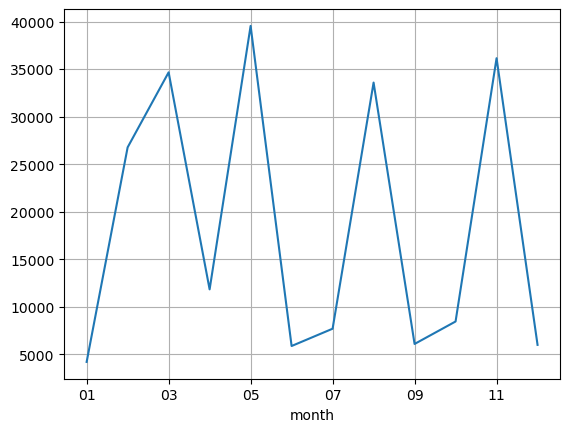

In [24]:
sent.groupby('month').size().plot()
plt.grid()
# plt.ylim(0, 50000)
plt.show()

In [25]:
ts_df1 = sent.groupby('year_month').agg(
    {
     'negative_financial_risk': 'mean',
     'positive_financial_risk': 'mean',
     'polarity_financial_risk': 'mean',
    }
)

ts_df2 = growth.groupby('year_month').agg(
    {
     'negative_growth_llama': 'mean',
     'positive_growth_llama': 'mean',
     'polarity_growth_llama': 'mean',
    }
)
ts_df = ts_df1.merge(ts_df2, on='year_month', how='outer')
ts_df = ts_df.reset_index()
ts_df


,year_month,negative_financial_risk,positive_financial_risk,polarity_financial_risk,negative_growth_llama,positive_growth_llama,polarity_growth_llama
0,200301,0.111060,0.248359,0.137299,0.156156,0.332257,0.176101
1,200302,0.111665,0.235943,0.124278,0.151144,0.338431,0.187286
2,200303,0.127806,0.227586,0.099781,0.175086,0.328939,0.153853
3,200304,0.118748,0.241338,0.122590,0.156367,0.338215,0.181847
4,200305,0.110969,0.237872,0.126903,0.144045,0.340987,0.196942
...,...,...,...,...,...,...,...
247,202308,0.147798,0.256271,0.108473,0.117581,0.336539,0.218959
248,202309,0.140184,0.277353,0.137169,0.158219,0.358082,0.199863
249,202310,0.139635,0.267778,0.128143,0.141059,0.334324,0.193265
250,202311,0.148284,0.266649,0.118365,0.118795,0.341247,0.222452


In [26]:
ts_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 252 entries, 0 to 251
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   year_month               252 non-null    object 
 1   negative_financial_risk  252 non-null    float64
 2   positive_financial_risk  252 non-null    float64
 3   polarity_financial_risk  252 non-null    float64
 4   negative_growth_llama    252 non-null    float64
 5   positive_growth_llama    252 non-null    float64
 6   polarity_growth_llama    252 non-null    float64
dtypes: float64(6), object(1)
memory usage: 13.9+ KB


In [27]:
jlmz_sent = pd.read_excel('JLMZ_MS_Index2017.xlsx')

jlmz_sent['year_month'] = jlmz_sent['date'].str.replace('-', '')
jlmz_sent.drop('date', axis=1, inplace=True)
jlmz_sent = jlmz_sent.rename(columns={'Manager Sentiment Index': 'msi'})

In [28]:
df = jlmz_sent.merge(ts_df, on='year_month', how='right')

In [29]:
df[['msi', 'polarity_financial_risk', 'polarity_growth_llama']].corr()

,msi,polarity_financial_risk,polarity_growth_llama
msi,1.000000,-0.074460,0.317112
polarity_financial_risk,-0.074460,1.000000,0.334885
polarity_growth_llama,0.317112,0.334885,1.000000


In [30]:
df['year_month'] = pd.to_datetime(df['year_month'], format='%Y%m')

df = df.sort_values('year_month')

window_size = 4

df['msi_ma_4m'] = df['msi'].rolling(window=window_size, center=False).mean()
df['polarity_financial_risk_ma_4m'] = df['polarity_financial_risk'].rolling(window=window_size, center=False).mean()
df['polarity_growth_llama_ma_4m'] = df['polarity_growth_llama'].rolling(window=window_size, center=False).mean()

In [31]:
df

,msi,year_month,negative_financial_risk,positive_financial_risk,polarity_financial_risk,negative_growth_llama,positive_growth_llama,polarity_growth_llama,msi_ma_4m,polarity_financial_risk_ma_4m,polarity_growth_llama_ma_4m
0,-1.574,2003-01-01,0.111060,0.248359,0.137299,0.156156,0.332257,0.176101,NaN,NaN,NaN
1,-3.172,2003-02-01,0.111665,0.235943,0.124278,0.151144,0.338431,0.187286,NaN,NaN,NaN
2,-3.555,2003-03-01,0.127806,0.227586,0.099781,0.175086,0.328939,0.153853,NaN,NaN,NaN
3,-4.065,2003-04-01,0.118748,0.241338,0.122590,0.156367,0.338215,0.181847,-3.0915,0.120987,0.174772
4,-4.146,2003-05-01,0.110969,0.237872,0.126903,0.144045,0.340987,0.196942,-3.7345,0.118388,0.179982
...,...,...,...,...,...,...,...,...,...,...,...
247,NaN,2023-08-01,0.147798,0.256271,0.108473,0.117581,0.336539,0.218959,NaN,0.110641,0.207736
248,NaN,2023-09-01,0.140184,0.277353,0.137169,0.158219,0.358082,0.199863,NaN,0.118299,0.203981
249,NaN,2023-10-01,0.139635,0.267778,0.128143,0.141059,0.334324,0.193265,NaN,0.124753,0.204229
250,NaN,2023-11-01,0.148284,0.266649,0.118365,0.118795,0.341247,0.222452,NaN,0.123038,0.208635


In [33]:
scaler = StandardScaler()
data_to_normalize = df[['msi_ma_4m', 'polarity_financial_risk_ma_4m', 'polarity_growth_llama_ma_4m']].dropna()
normalized_data = scaler.fit_transform(data_to_normalize)
normalized_data

normalized_df = pd.DataFrame(normalized_data, 
                            columns=['msi_ma_4m_norm', 'polarity_financial_risk_ma_4m_norm', 'polarity_growth_llama_ma_4m_norm'],
                            index=data_to_normalize.index)

dates_for_normalized = df.loc[normalized_df.index, 'year_month']
normalized_df['year_month'] = dates_for_normalized
normalized_df = normalized_df.reset_index(drop=True)

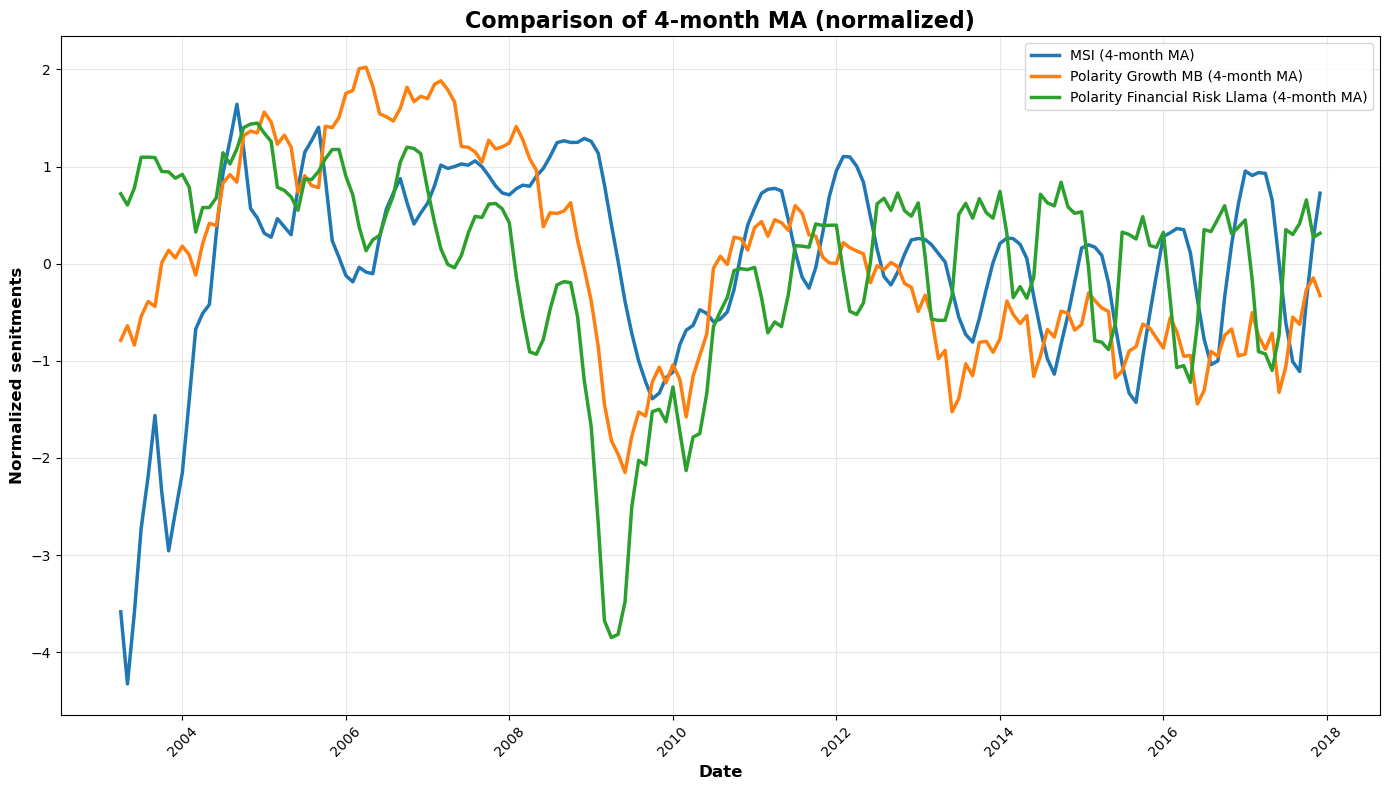

In [35]:
fig2, ax2 = plt.subplots(figsize=(14, 8))

ax2.plot(dates_for_normalized, normalized_df['msi_ma_4m_norm'], 
         label='MSI (4-month MA)', 
         linewidth=2.5)

ax2.plot(dates_for_normalized, normalized_df['polarity_growth_llama_ma_4m_norm'], 
         label='Polarity Growth MB (4-month MA)', 
         linewidth=2.5)

ax2.plot(dates_for_normalized, normalized_df['polarity_financial_risk_ma_4m_norm'], 
         label='Polarity Financial Risk Llama (4-month MA)', 
         linewidth=2.5)

ax2.set_title('Comparison of 4-month MA (normalized)', 
              fontsize=16, fontweight='bold')
ax2.set_xlabel('Date', fontsize=12, fontweight='bold')
ax2.set_ylabel('Normalized senitments', fontsize=12, fontweight='bold')
ax2.legend(loc='best')
ax2.grid(True, alpha=0.3)

plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('figures/financial_risk_growth.png')
plt.show()

## Model

Rmt+1 (the monthly return on the S&P 500 index in excess of the risk-free rate

In [36]:
predictor_data = pd.read_excel('PredictorData2024.xlsx')

In [37]:
predictor_data.tail()

,yyyymm,Index,D12,E12,b/m,tbl,AAA,BAA,lty,ntis,Rfree,infl,ltr,corpr,svar,csp,CRSP_SPvw,CRSP_SPvwx
1843,202408,5648.40,72.925466,198.823333,0.187377,0.0505,0.0487,0.0560,0.0387,-0.011028,0.0048,0.000814,0.012792,0.015726,0.003184,NaN,0.024283,0.022898
1844,202409,5762.48,73.400300,200.270000,0.183981,0.0472,0.0468,0.0542,0.0372,-0.010283,0.0040,0.001604,0.012023,0.017730,0.001466,NaN,0.022821,0.021707
1845,202410,5705.45,73.877618,203.570000,0.186478,0.0451,0.0495,0.0563,0.0410,-0.009458,0.0039,0.001151,-0.023811,-0.024271,0.001062,NaN,-0.008690,-0.009523
1846,202411,6032.38,74.354936,206.870000,0.173410,0.0442,0.0514,0.0578,0.0436,-0.004121,0.0040,-0.000542,0.007772,0.013377,0.001264,NaN,0.060420,0.059016
1847,202412,5881.63,74.832255,210.170000,0.183056,0.0427,0.0520,0.0580,0.0439,-0.004614,0.0037,0.000355,-0.015408,-0.019354,0.001643,NaN,-0.023445,-0.024621


In [38]:
data = predictor_data[predictor_data['yyyymm'] > 200211].copy().reset_index(drop=True)
data['year_month'] = pd.to_datetime(data['yyyymm'], format='%Y%m')

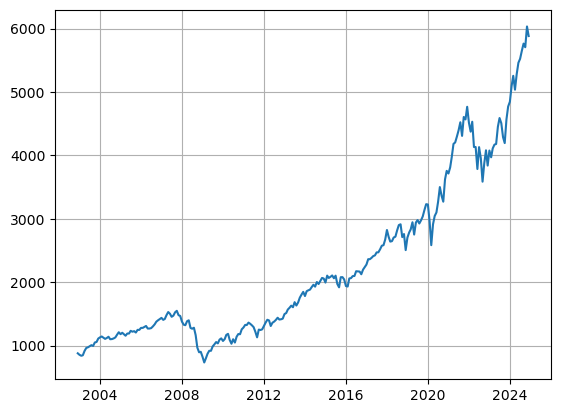

In [39]:
plt.plot(data['year_month'], data['Index'])
plt.grid()

In [40]:
data = data.sort_values('year_month')

In [41]:
data['index_return'] = data['Index'].pct_change()
data['target'] = data['index_return'] - data['Rfree']

data = data.merge(normalized_df, on='year_month', how='left')

In [43]:
data

,yyyymm,Index,D12,E12,b/m,tbl,AAA,BAA,lty,ntis,Rfree,infl,ltr,corpr,svar,csp,CRSP_SPvw,CRSP_SPvwx,year_month,index_return,target,msi_ma_4m_norm,polarity_financial_risk_ma_4m_norm,polarity_growth_llama_ma_4m_norm
0,200212,879.82,16.074000,27.590000,0.295386,0.0119,0.0621,0.0745,0.0484,0.025736,0.0011,-0.002206,0.050700,0.036100,0.002640,-0.004144,-0.058834,-0.060464,2002-12-01,NaN,NaN,NaN,NaN,NaN
1,200301,855.70,16.124000,28.500000,0.305942,0.0117,0.0617,0.0735,0.0495,0.028289,0.0010,0.004422,-0.010600,0.002100,0.005168,NaN,-0.026579,-0.027860,2003-01-01,-0.027415,-0.028415,NaN,NaN,NaN
2,200302,841.15,16.174000,29.410000,0.312251,0.0117,0.0595,0.0706,0.0472,0.027919,0.0009,0.007705,0.032900,0.026400,0.002564,NaN,-0.015246,-0.017225,2003-02-01,-0.017004,-0.017904,NaN,NaN,NaN
3,200303,848.18,16.224000,30.320000,0.286118,0.0113,0.0589,0.0695,0.0486,0.024099,0.0010,0.006008,-0.013500,-0.008000,0.006136,NaN,0.010308,0.008967,2003-03-01,0.008358,0.007358,NaN,NaN,NaN
4,200304,916.92,16.204333,31.730000,0.269654,0.0113,0.0574,0.0685,0.0481,0.019967,0.0010,-0.002172,0.010200,0.022900,0.003065,NaN,0.082774,0.081462,2003-04-01,0.081044,0.080044,-3.584048,0.719742,-0.788999
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
260,202408,5648.40,72.925466,198.823333,0.187377,0.0505,0.0487,0.0560,0.0387,-0.011028,0.0048,0.000814,0.012792,0.015726,0.003184,NaN,0.024283,0.022898,2024-08-01,0.022835,0.018035,NaN,NaN,NaN
261,202409,5762.48,73.400300,200.270000,0.183981,0.0472,0.0468,0.0542,0.0372,-0.010283,0.0040,0.001604,0.012023,0.017730,0.001466,NaN,0.022821,0.021707,2024-09-01,0.020197,0.016197,NaN,NaN,NaN
262,202410,5705.45,73.877618,203.570000,0.186478,0.0451,0.0495,0.0563,0.0410,-0.009458,0.0039,0.001151,-0.023811,-0.024271,0.001062,NaN,-0.008690,-0.009523,2024-10-01,-0.009897,-0.013797,NaN,NaN,NaN
263,202411,6032.38,74.354936,206.870000,0.173410,0.0442,0.0514,0.0578,0.0436,-0.004121,0.0040,-0.000542,0.007772,0.013377,0.001264,NaN,0.060420,0.059016,2024-11-01,0.057301,0.053301,NaN,NaN,NaN


### Control variables

we use 14 monthly economic variables that are linked directly to macroeconomic fundamentals, which are 
- the log dividend-price ratio (DP): log of a 12-month moving sum of dividends paid on the S&P 500 index minus the log of stock prices (S&P 500 index) 
- log dividend yield (DY): difference between the log of dividends and the log of lagged prices
- log earnings-price ratio (EP): difference between the log of earnings on the S&P 500 index and the log of prices, where earnings is measured using a one-year moving sum 
- log dividend-payout ratio (DE): difference between the log of dividends and the log of earnings on the S&P 500 index
- stock return variance (SVAR),
- book-to-market ratio (BM),
- net equity expansion (NTIS),
- Treasury bill rate (TBL), 
- long-term bond yield (LTY),
- long-term bond return (LTR), 
- term spread (TMS): difference between the long-term yield and the Treasury bill rate
- default yield spread (DFY): difference between BAA- and AAA-rated corporate bond yields
- default return spread (DFR): difference between the long-term corporate bond return and the long-term government bond return.
- inflation rate (INFL).

In [44]:
data['log_DP'] = np.log(data['D12']) - np.log(data['Index'])

data['lag_Index'] = data['Index'].shift(1)
data['log_DY'] = np.log(data['D12']) - np.log(data['lag_Index'])

data['log_EP'] = np.log(data['E12']) - np.log(data['Index'])
data['log_DE'] = np.log(data['D12']) - np.log(data['E12'])
data['tms'] = data['lty'] - data['tbl']
data['dfy'] = data['BAA'] - data['AAA']
data['dfr'] = data['corpr'] - data['ltr']

In [45]:
data = data.rename(columns={'b/m': 'bm'})

In [46]:
# control_variables = ['log_DP', 'log_DY', 'log_EP', 'log_DE', 'svar', 'b/m', 'ntis', 'tbl', 'lty', 'ltr', 'tms', 'dfy', 'dfr', 'infl']
control_variables = ['log_DP', 'log_EP', 'svar', 'bm', 'ntis', 'tbl', 'lty', 'ltr', 'tms', 'dfy', 'dfr', 'infl']
len(control_variables)

12

In [47]:
data

,yyyymm,Index,D12,E12,bm,tbl,AAA,BAA,lty,ntis,Rfree,infl,ltr,corpr,svar,csp,CRSP_SPvw,CRSP_SPvwx,year_month,index_return,target,msi_ma_4m_norm,polarity_financial_risk_ma_4m_norm,polarity_growth_llama_ma_4m_norm,log_DP,lag_Index,log_DY,log_EP,log_DE,tms,dfy,dfr
0,200212,879.82,16.074000,27.590000,0.295386,0.0119,0.0621,0.0745,0.0484,0.025736,0.0011,-0.002206,0.050700,0.036100,0.002640,-0.004144,-0.058834,-0.060464,2002-12-01,NaN,NaN,NaN,NaN,NaN,-4.002514,NaN,NaN,-3.462264,-0.540250,0.0365,0.0124,-0.014600
1,200301,855.70,16.124000,28.500000,0.305942,0.0117,0.0617,0.0735,0.0495,0.028289,0.0010,0.004422,-0.010600,0.002100,0.005168,NaN,-0.026579,-0.027860,2003-01-01,-0.027415,-0.028415,NaN,NaN,NaN,-3.971611,879.82,-3.999408,-3.402016,-0.569595,0.0378,0.0118,0.012700
2,200302,841.15,16.174000,29.410000,0.312251,0.0117,0.0595,0.0706,0.0472,0.027919,0.0009,0.007705,0.032900,0.026400,0.002564,NaN,-0.015246,-0.017225,2003-02-01,-0.017004,-0.017904,NaN,NaN,NaN,-3.951365,855.70,-3.968515,-3.353435,-0.597930,0.0355,0.0111,-0.006500
3,200303,848.18,16.224000,30.320000,0.286118,0.0113,0.0589,0.0695,0.0486,0.024099,0.0010,0.006008,-0.013500,-0.008000,0.006136,NaN,0.010308,0.008967,2003-03-01,0.008358,0.007358,NaN,NaN,NaN,-3.956601,841.15,-3.948278,-3.331285,-0.625316,0.0373,0.0106,0.005500
4,200304,916.92,16.204333,31.730000,0.269654,0.0113,0.0574,0.0685,0.0481,0.019967,0.0010,-0.002172,0.010200,0.022900,0.003065,NaN,0.082774,0.081462,2003-04-01,0.081044,0.080044,-3.584048,0.719742,-0.788999,-4.035742,848.18,-3.957814,-3.363758,-0.671984,0.0368,0.0111,0.012700
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
260,202408,5648.40,72.925466,198.823333,0.187377,0.0505,0.0487,0.0560,0.0387,-0.011028,0.0048,0.000814,0.012792,0.015726,0.003184,NaN,0.024283,0.022898,2024-08-01,0.022835,0.018035,NaN,NaN,NaN,-4.349690,5522.30,-4.327112,-3.346711,-1.002979,-0.0118,0.0073,0.002934
261,202409,5762.48,73.400300,200.270000,0.183981,0.0472,0.0468,0.0542,0.0372,-0.010283,0.0040,0.001604,0.012023,0.017730,0.001466,NaN,0.022821,0.021707,2024-09-01,0.020197,0.016197,NaN,NaN,NaN,-4.363195,5648.40,-4.343200,-3.359457,-1.003738,-0.0100,0.0074,0.005707
262,202410,5705.45,73.877618,203.570000,0.186478,0.0451,0.0495,0.0563,0.0410,-0.009458,0.0039,0.001151,-0.023811,-0.024271,0.001062,NaN,-0.008690,-0.009523,2024-10-01,-0.009897,-0.013797,NaN,NaN,NaN,-4.346767,5762.48,-4.356713,-3.333167,-1.013600,-0.0041,0.0068,-0.000460
263,202411,6032.38,74.354936,206.870000,0.173410,0.0442,0.0514,0.0578,0.0436,-0.004121,0.0040,-0.000542,0.007772,0.013377,0.001264,NaN,0.060420,0.059016,2024-11-01,0.057301,0.053301,NaN,NaN,NaN,-4.396047,5705.45,-4.340327,-3.372806,-1.023241,-0.0006,0.0064,0.005605


In [48]:
data[control_variables].describe()

,log_DP,log_EP,svar,bm,ntis,tbl,lty,ltr,tms,dfy,dfr,infl
count,265.000000,265.000000,265.000000,265.000000,265.000000,265.000000,265.000000,265.000000,265.000000,265.000000,265.000000,265.000000
mean,-3.989553,-3.122190,0.002939,0.284885,-0.006511,0.015557,0.034194,0.004385,0.018636,0.010253,0.000647,0.002102
std,0.172141,0.353958,0.006649,0.059840,0.016852,0.017921,0.012188,0.030807,0.015737,0.004121,0.019313,0.003945
min,-4.396047,-4.836478,0.000150,0.173410,-0.055954,0.000100,0.006200,-0.112400,-0.015700,0.005500,-0.097600,-0.019153
25%,-4.074094,-3.201425,0.000746,0.238168,-0.017425,0.000900,0.025800,-0.015330,0.005800,0.007900,-0.006600,-0.000354
50%,-3.973667,-3.086025,0.001363,0.286118,-0.008504,0.009000,0.034900,0.002438,0.019200,0.009300,0.000700,0.002017
75%,-3.899373,-2.911181,0.002705,0.330671,0.007936,0.023900,0.044900,0.023000,0.032300,0.011300,0.008000,0.004741
max,-3.281006,-2.565551,0.073153,0.446141,0.028289,0.053400,0.054200,0.144300,0.045300,0.033800,0.073700,0.013736


In [49]:
data[control_variables].corr()

,log_DP,log_EP,svar,bm,ntis,tbl,lty,ltr,tms,dfy,dfr,infl
log_DP,1.000000,-0.270335,0.389299,0.755450,-0.401352,-0.420511,-0.045138,0.117388,0.443922,0.724724,-0.039346,-0.287781
log_EP,-0.270335,1.000000,-0.184919,0.049014,0.249237,0.108182,0.068357,0.070199,-0.070259,-0.527193,-0.219181,-0.000252
svar,0.389299,-0.184919,1.000000,0.156341,-0.238764,-0.129036,-0.062083,0.205030,0.098866,0.512920,-0.366515,-0.284670
bm,0.755450,0.049014,0.156341,1.000000,0.109420,-0.470258,0.118737,0.107927,0.627488,0.426404,-0.008101,-0.200219
ntis,-0.401352,0.249237,-0.238764,0.109420,1.000000,-0.231569,0.103314,0.017893,0.343724,-0.451915,0.039535,0.117523
tbl,-0.420511,0.108182,-0.129036,-0.470258,-0.231569,1.000000,0.508336,-0.005418,-0.745119,-0.188836,-0.037914,0.064805
lty,-0.045138,0.068357,-0.062083,0.118737,0.103314,0.508336,1.000000,-0.049977,0.195563,0.042768,-0.019754,0.022932
ltr,0.117388,0.070199,0.205030,0.107927,0.017893,-0.005418,-0.049977,1.000000,-0.032535,0.069529,-0.396099,-0.265620
tms,0.443922,-0.070259,0.098866,0.627488,0.343724,-0.745119,0.195563,-0.032535,1.000000,0.248170,0.027878,-0.056040
dfy,0.724724,-0.527193,0.512920,0.426404,-0.451915,-0.188836,0.042768,0.069529,0.248170,1.000000,0.093000,-0.267343


## Table 2

In [50]:
target = 'target'

In [51]:
data[f'index_return'] = data['Index'].pct_change(periods=1)
data['index_return'] = (data['index_return'] - data['Rfree'])

data['cum_return'] = (1 + data['index_return']).cumprod()
data['net_cum_return'] = data['cum_return'] - 1

In [52]:
return_names = []

for period in [1, 3, 6, 9, 12, 24, 36]:
    return_names.append(f'net_cum_return{period}')

In [53]:
for i in data.index:
    
    working_data = data.loc[i:i+37].copy()
    working_data['net_cum_return'] = (1 + working_data['index_return']).cumprod() - 1

    for period in [1, 3, 6, 9, 12, 24, 36]:

        working_data[f'net_cum_return{period}'] = working_data['net_cum_return'].shift(periods=-period)
    
    data.loc[i, return_names] = working_data[return_names].iloc[0]

In [54]:
# data[return_names] = data[return_names] * 100

In [55]:
data = data.merge(df, on='year_month', how='left')

In [59]:
for sentiment in ['msi', 
                  'negative_growth_llama', 'positive_growth_llama', 'polarity_growth_llama',
                  'negative_financial_risk', 'positive_financial_risk', 'polarity_financial_risk']:

    ss = StandardScaler()
    data[f"{sentiment}_norm"] = ss.fit_transform(data[[sentiment]])

In [60]:
[col for col in data.columns if 'msi' in col]

['msi_ma_4m_norm', 'msi', 'msi_ma_4m', 'msi_norm']

In [61]:
[col for col in data.columns if 'financial' in col]

['polarity_financial_risk_ma_4m_norm',
 'negative_financial_risk',
 'positive_financial_risk',
 'polarity_financial_risk',
 'polarity_financial_risk_ma_4m',
 'negative_financial_risk_norm',
 'positive_financial_risk_norm',
 'polarity_financial_risk_norm']

In [62]:
data_ = data[data['yyyymm'].between(200301, 201412)].copy().reset_index(drop=True)

In [63]:
features_res, table_res = fit_one_factor(data_, 'msi_norm', return_names)
table_res

,coef,t,r2_adj,pval
net_cum_return1,-0.018**,-2.403,9.079,0.016
net_cum_return3,-0.035***,-2.689,15.392,0.007
net_cum_return6,-0.049***,-2.577,15.59,0.01
net_cum_return9,-0.063***,-2.815,17.681,0.005
net_cum_return12,-0.065***,-2.567,14.847,0.01
net_cum_return24,-0.074*,-1.949,8.831,0.051
net_cum_return36,-0.081**,-2.037,6.883,0.042


In [117]:
features_res, table_res = fit_one_factor(data_, 'polarity_financial_risk', return_names)
table_res

,coef,t,r2_adj,pval
net_cum_return1,-0.201,-0.839,0.119,0.401
net_cum_return3,-0.238,-0.516,-0.176,0.606
net_cum_return6,-0.528,-0.678,0.622,0.498
net_cum_return9,-0.887,-0.974,1.871,0.33
net_cum_return12,-1.243,-1.363,3.327,0.173
net_cum_return24,-2.786**,-2.382,8.768,0.017
net_cum_return36,-4.134***,-3.714,13.342,0.0


In [120]:
features_res, table_res = fit_one_factor(data, 'polarity_financial_risk_ma_4m_norm', return_names)
table_res

,coef,t,r2_adj,pval
net_cum_return1,-0.004,-0.596,-0.085,0.551
net_cum_return3,-0.008,-0.569,0.254,0.57
net_cum_return6,-0.016,-0.862,1.381,0.389
net_cum_return9,-0.027,-1.398,3.084,0.162
net_cum_return12,-0.037**,-2.175,4.903,0.03
net_cum_return24,-0.082***,-3.141,12.048,0.002
net_cum_return36,-0.119***,-3.903,17.447,0.0


In [121]:
features_res, table_res = fit_one_factor(data, 'polarity_financial_risk_ma_4m_norm', return_names, control_variables)
table_res

,coef,t,r2_adj,pval
net_cum_return1,-0.002,-0.226,32.017,0.821
net_cum_return3,0.017,1.63,41.522,0.103
net_cum_return6,0.033***,2.73,52.911,0.006
net_cum_return9,0.028**,2.12,55.847,0.034
net_cum_return12,0.022,1.434,53.986,0.152
net_cum_return24,0.057***,2.623,76.666,0.009
net_cum_return36,0.003,0.187,85.603,0.852


In [122]:
features_res, table_res = fit_one_factor(data, 'polarity_growth_llama_ma_4m_norm', return_names)
table_res

,coef,t,r2_adj,pval
net_cum_return1,-0.013**,-2.132,4.774,0.033
net_cum_return3,-0.026**,-2.197,9.461,0.028
net_cum_return6,-0.047**,-2.417,15.743,0.016
net_cum_return9,-0.067***,-2.59,22.69,0.01
net_cum_return12,-0.083***,-2.695,27.541,0.007
net_cum_return24,-0.149***,-3.708,41.033,0.0
net_cum_return36,-0.203***,-5.62,51.605,0.0


In [95]:
res_ = ols_new_west(data, x_vars=['polarity_growth_llama_norm', 'polarity_financial_risk_norm'],
                    target='net_cum_return36')
print(res_.summary())

                            OLS Regression Results                            
Dep. Variable:       net_cum_return36   R-squared:                       0.336
Model:                            OLS   Adj. R-squared:                  0.330
Method:                 Least Squares   F-statistic:                     11.49
Date:                Fri, 27 Mar 2026   Prob (F-statistic):           1.78e-05
Time:                        13:00:14   Log-Likelihood:                 25.441
No. Observations:                 228   AIC:                            -44.88
Df Residuals:                     225   BIC:                            -34.59
Df Model:                           2                                         
Covariance Type:                  HAC                                         
                                   coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------
Intercept       

In [102]:
res_ = ols_new_west(data, x_vars=['polarity_growth_llama_norm', 'positive_financial_risk_norm'],
                    target='net_cum_return36')
print(res_.summary())

                            OLS Regression Results                            
Dep. Variable:       net_cum_return36   R-squared:                       0.335
Model:                            OLS   Adj. R-squared:                  0.329
Method:                 Least Squares   F-statistic:                     14.40
Date:                Fri, 27 Mar 2026   Prob (F-statistic):           1.31e-06
Time:                        13:00:41   Log-Likelihood:                 25.209
No. Observations:                 228   AIC:                            -44.42
Df Residuals:                     225   BIC:                            -34.13
Df Model:                           2                                         
Covariance Type:                  HAC                                         
                                   coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------
Intercept       

In [109]:
res_ = ols_new_west(data, x_vars=['polarity_growth_llama_norm', 'negative_financial_risk_norm'],
                    target='net_cum_return36')
print(res_.summary())

                            OLS Regression Results                            
Dep. Variable:       net_cum_return36   R-squared:                       0.334
Model:                            OLS   Adj. R-squared:                  0.328
Method:                 Least Squares   F-statistic:                     8.205
Date:                Fri, 27 Mar 2026   Prob (F-statistic):           0.000364
Time:                        13:01:11   Log-Likelihood:                 25.164
No. Observations:                 228   AIC:                            -44.33
Df Residuals:                     225   BIC:                            -34.04
Df Model:                           2                                         
Covariance Type:                  HAC                                         
                                   coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------
Intercept       